# 09 · A real example: Sep-2026 calcite in HCl (takes 260910_011 and 260910_016)

This is what **real** data look like, and what the standard analysis gives. The notebook was executed on the
lab machine where the recordings live (1.2 GB each, not in the repository), and its outputs are saved here,
so you can read it without the files. The same figure sets are in `examples/real_260910_011/` and
`examples/real_260910_016/`.

Setup: 4 channels at 192 kHz (two hydrophones on opposite sides of the crystal, a contact sensor bonded to
it, an air mic as veto). An active chirp every 10 s is masked. Take 011 is 1 M HCl, with the sample dropped
at ~33 s, acid at ~45 s and a second addition at ~250 s. Take 016 is 0.5 M.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/real_example_sep2026.yaml"

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/real_example_sep2026.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/experiment/Dataset2_ThusSep10/passive
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/cache/sep2026_example
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/examples


In [3]:
takes = za.discover_takes(cfg.data_dir, recursive=cfg.recursive, pattern=cfg.file_pattern)
za.process_all(takes, cfg, verbose=False)
za.takes_table(takes)

,take,start,duration_s,sr,n_channels,channels,tracks,n_parts,n_files,subtype,size_GB
0,260910_011,2026-09-10 15:33:20,384.985,192000,4,"1,2,3,4","Tr1,Tr2,Tr3,Tr4",1,1,FLOAT,1.183
1,260910_016,2026-09-10 16:21:20,390.924,192000,4,"1,2,3,4","Tr1,Tr2,Tr3,Tr4",1,1,FLOAT,1.201


## Take 011: full range, zooms, difference image

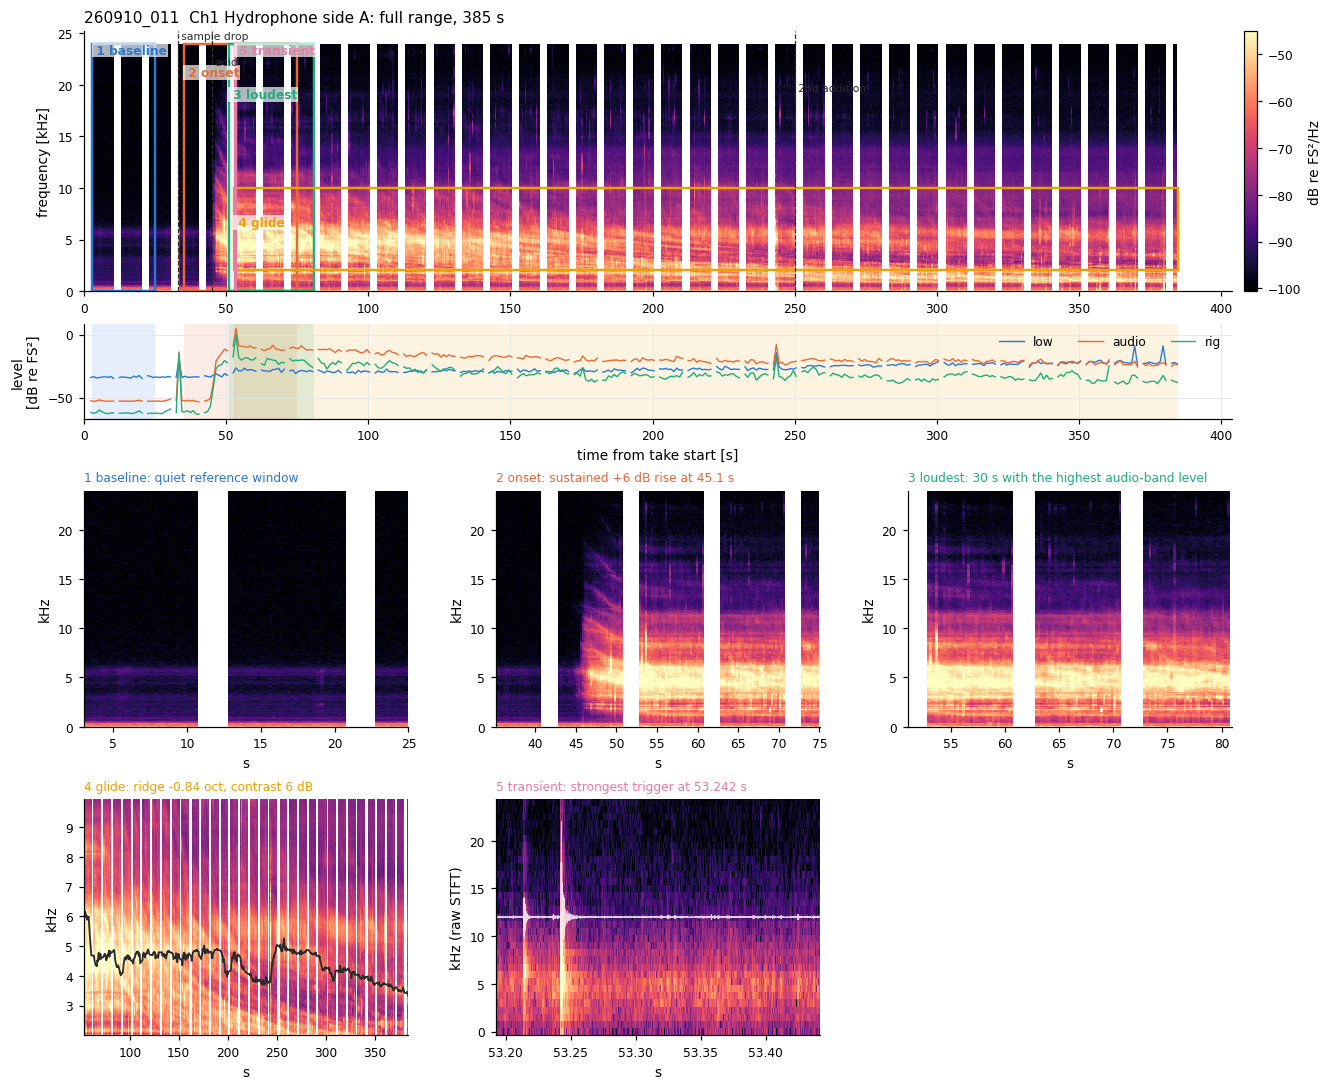

In [4]:
f = za.load_features(cfg, "260910_011")
take = za.find_take(takes, "260910_011")
MARK = {"sample drop": 33.0, "acid": 45.0, "2nd addition": 250.0}
z = za.views.suggest_zooms(f, 1, baseline=(3, 25))
fig = za.views.plot_overview_zoom(f, 1, z, take=take, markers=MARK)

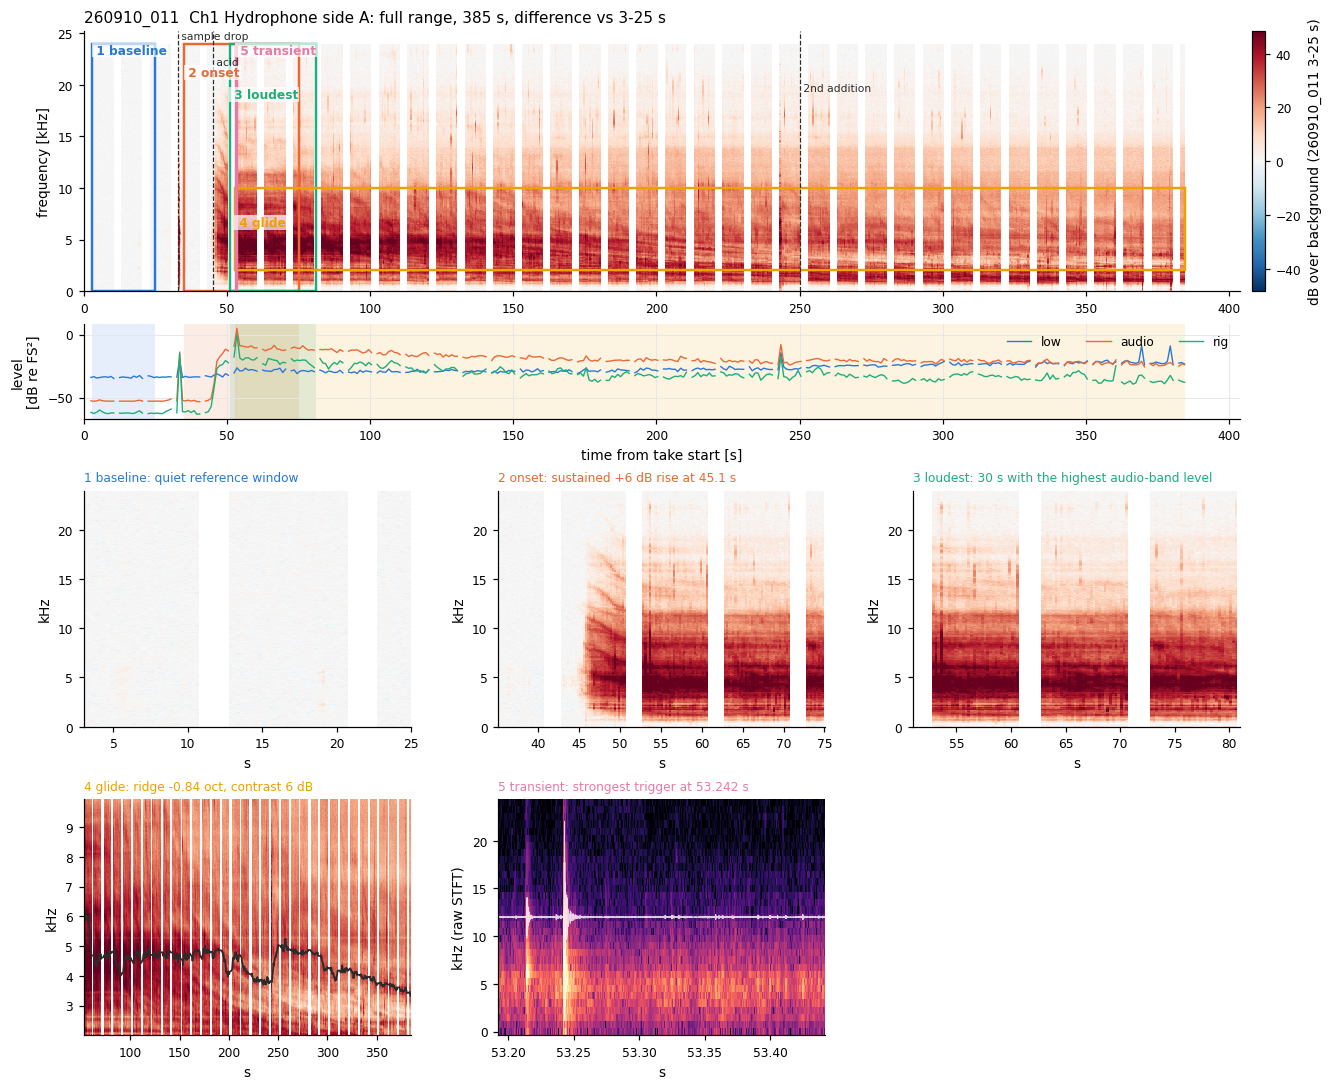

In [5]:
fig = za.views.plot_overview_zoom(f, 1, z, take=take, markers=MARK, background=(3, 25))

**Read it like this.** Before the acid only the 5.6 kHz apparatus line and low-frequency room noise are
present. At acid contact (~45 s) all wetted channels rise by 13–35 dB in the audio band. Right after the
onset there is a fan of parallel descending ridges. The air mic rises by only ~2 dB, so the sound is
liquid/solid-borne. The contact sensor responds strongly to the second addition at ~250 s.

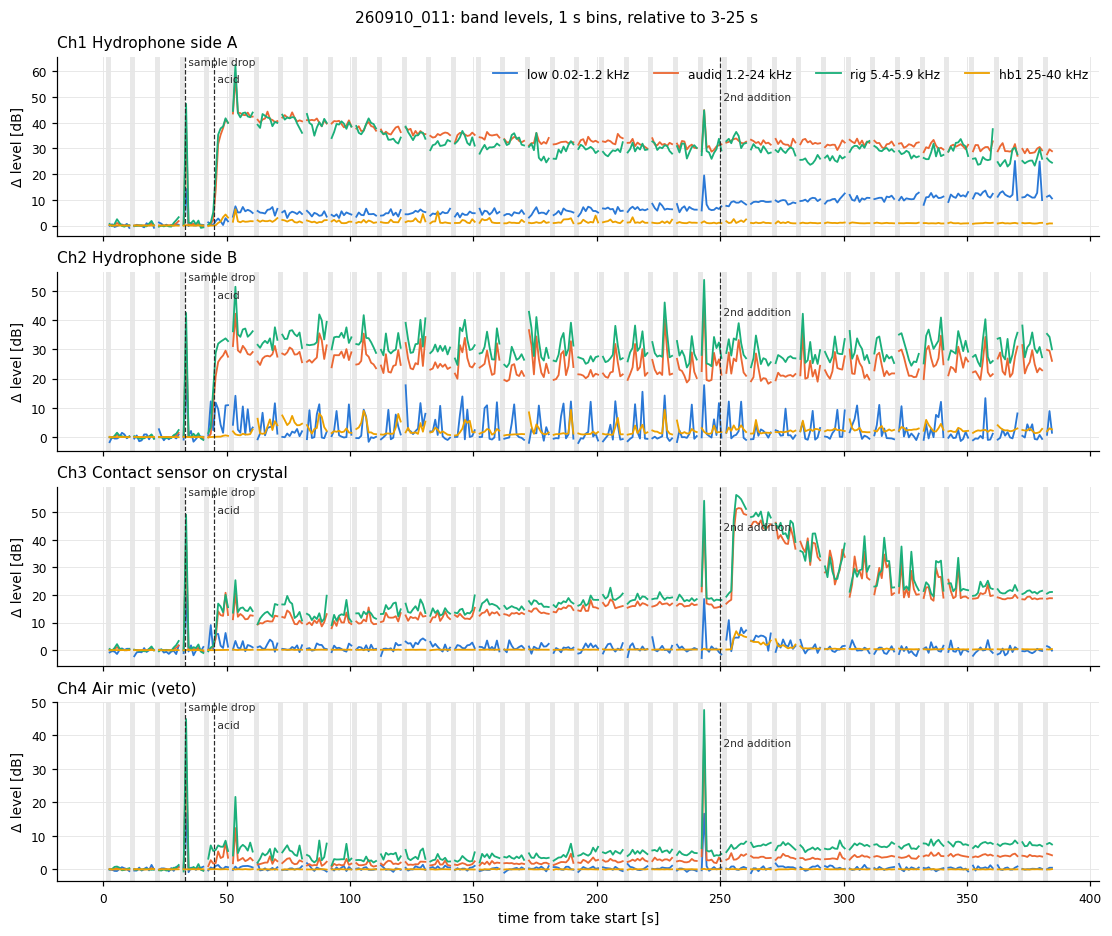

In [6]:
fig = zp.plot_levels(f, bands=("low", "audio", "rig", "hb1"), dt=1.0, relative_to=(3, 25), markers=MARK)

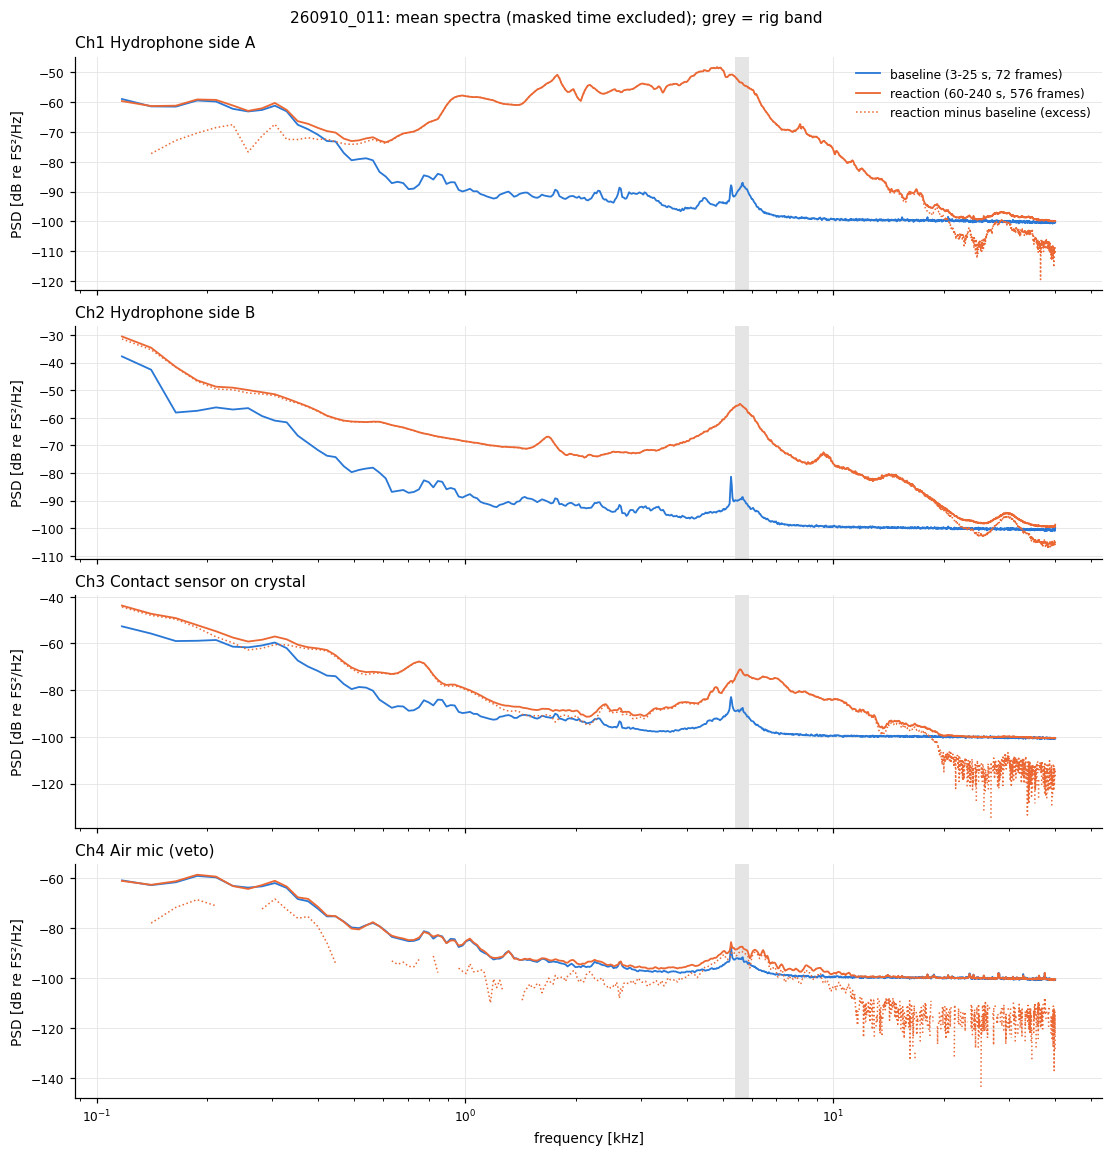

In [7]:
fig = zp.plot_psd(f, {"baseline": (3, 25), "reaction": (60, 240)}, fmax=40000, fmin=100, excess=True)

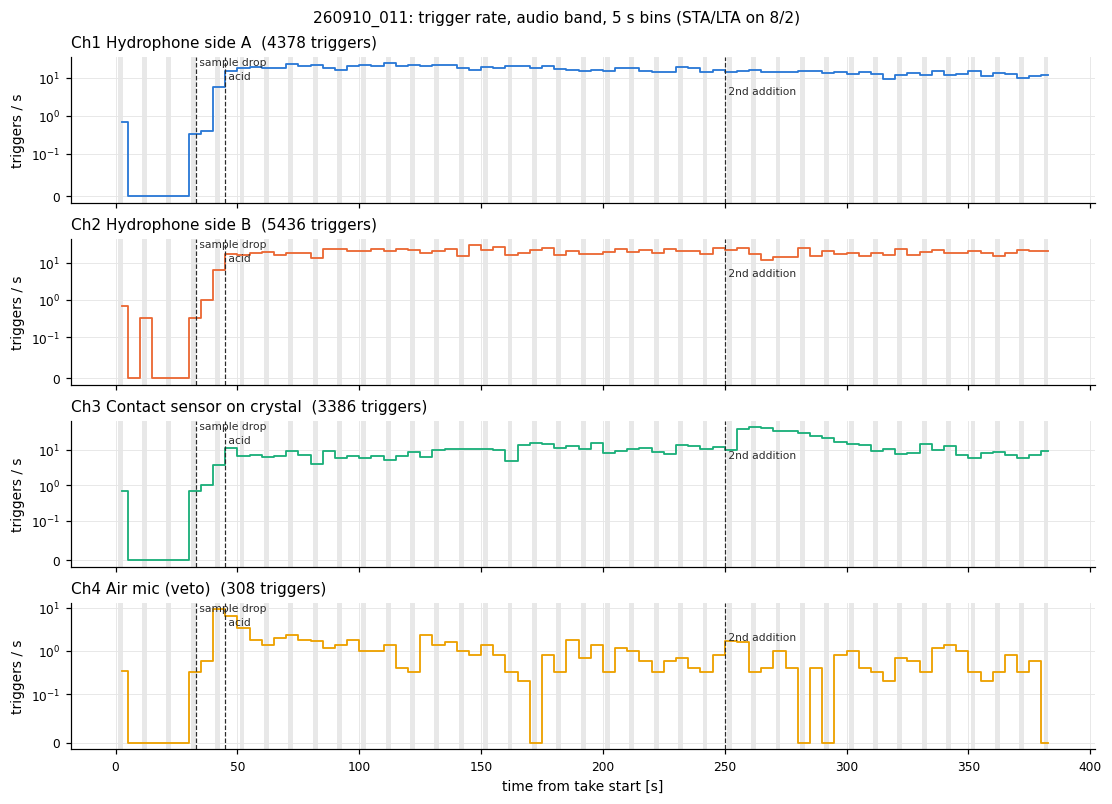

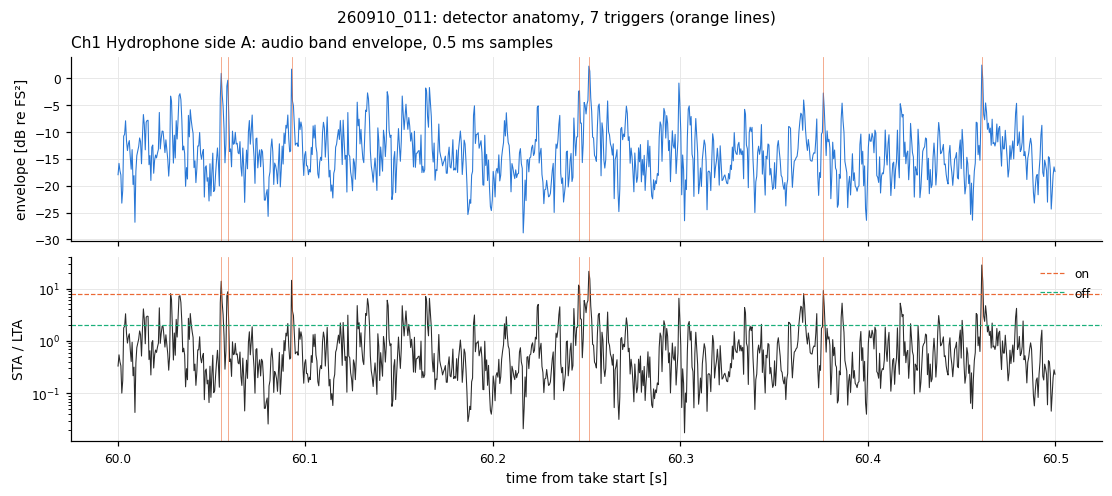

In [8]:
fig = zp.plot_event_rate(f, "audio", bin_s=5.0, markers=MARK)
fig = zp.plot_detector(f, 1, "audio", 60.0, 60.5)

## Take 016: the strongest glide, and what it would require

In [9]:
from zoom_acoustics import glide as G
f16 = za.load_features(cfg, "260910_016")
tracks, rows = {}, []
for c in f16.channels:
    tr = G.track_ridge(f16, c, (3, 25), 49.5, seed=(4000, 12000))
    s = G.summarize(tr)
    tracks[c] = tr
    rows.append(dict(channel=c, label=f16.label(c), **s))
pd.DataFrame(rows)[["channel", "label", "f_start_hz", "f_end_hz", "octaves", "median_contrast_db", "significant"]].round(2)

,channel,label,f_start_hz,f_end_hz,octaves,median_contrast_db,significant
0,1,Ch1 Hydrophone side A,6298.03,1002.39,-2.65,6.42,True
1,2,Ch2 Hydrophone side B,5547.60,4471.14,-0.31,5.50,False
2,3,Ch3 Contact sensor on crystal,6762.14,4566.33,-0.57,4.31,False
3,4,Ch4 Air mic (veto),6217.82,6445.08,0.05,3.85,False


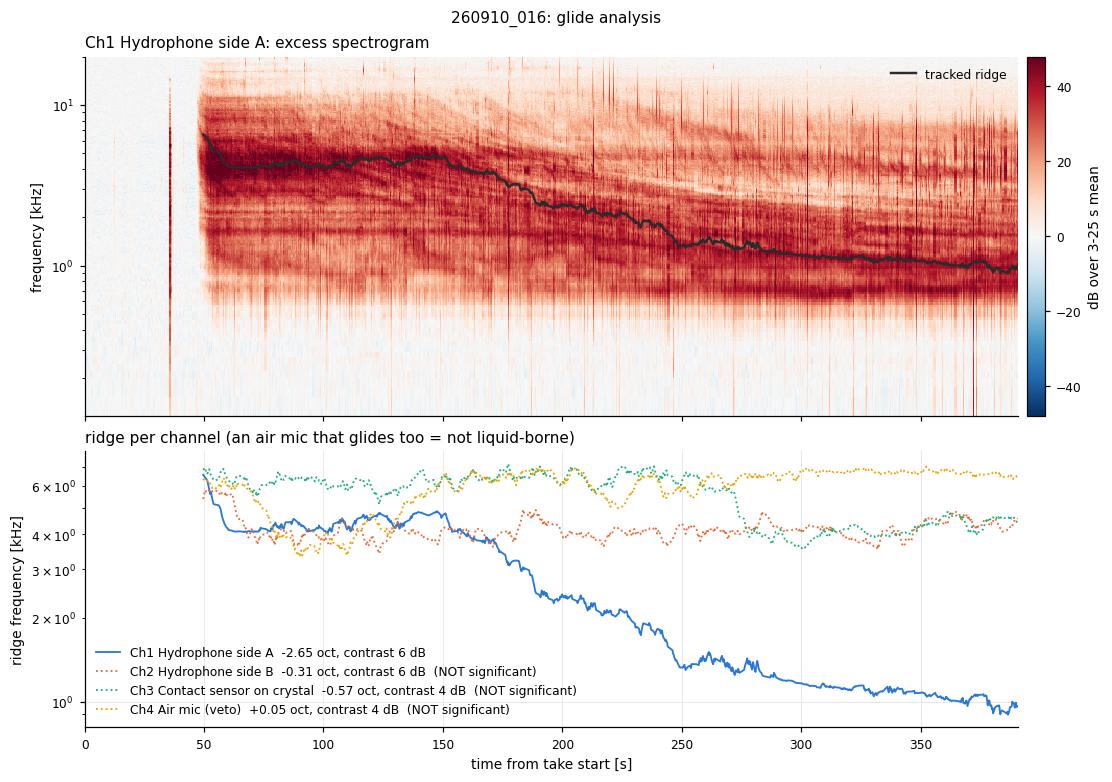

In [10]:
fig = zp.plot_glide(f16, tracks, (3, 25), show_ch=1)

,hypothesis,requires,physical,note
0,A: one free bubble growing,"R 0.54-3.32 mm, median dR/dt 4.2 um/s",False,Bond max 1.49 (>= 1 impossible as a free sphere)
1,A': bubble touching a wall,R 0.44-2.71 mm,True,"a wall lowers f (x0.816 touching), so the SAME..."
2,"B: bubbly layer, thickness 5mm",void fraction 9.5e-03-2.0e-02,False,beta must RISE as f falls; check against gas p...
3,"B: bubbly layer, thickness 10mm",void fraction 2.3e-03-2.0e-02,False,beta must RISE as f falls; check against gas p...
4,"B: bubbly layer, thickness 20mm",void fraction 5.3e-04-2.0e-02,False,beta must RISE as f falls; check against gas p...
5,"B: bubbly layer, thickness 40mm",void fraction 8.8e-05-5.6e-03,True,beta must RISE as f falls; check against gas p...


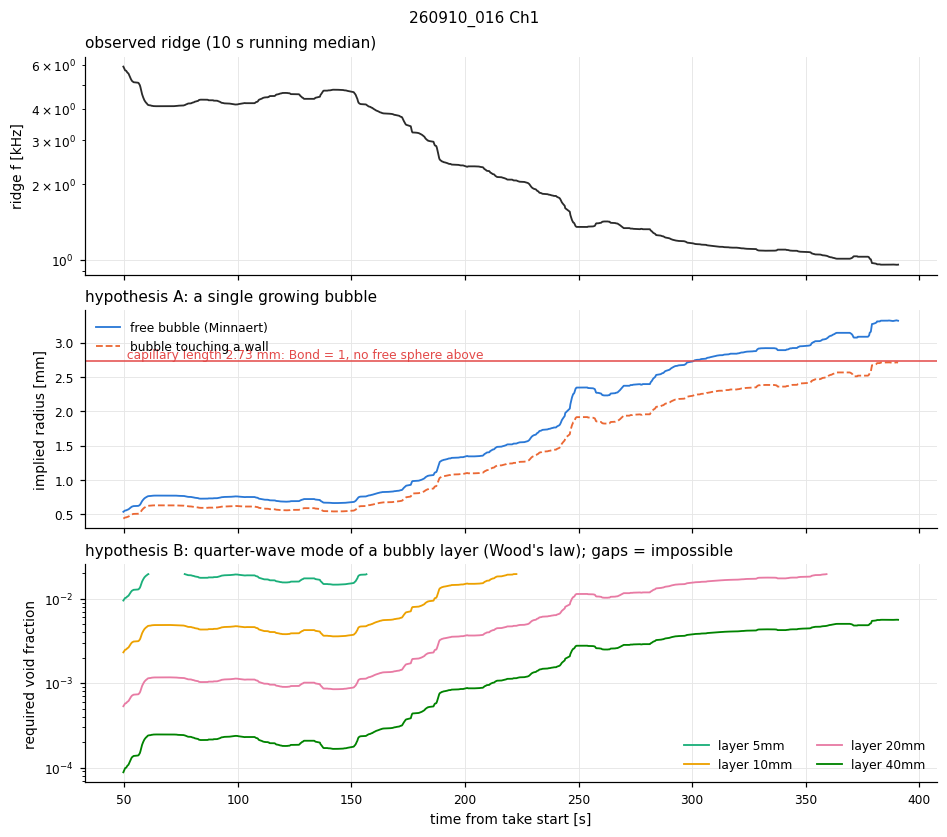

In [11]:
it = G.interpret(tracks[1])
fig = zp.plot_glide_interpretation(it, "260910_016 Ch1")
G.interpretation_summary(it)

In [12]:
G.harmonic_ladder(f16, 1, (3, 25), tracks[1]).round(2)

,multiple,control,n_frames,median_contrast_dB,frac_above_3dB
0,0.5,False,1127,2.51,0.46
1,1.0,False,1127,7.31,0.85
2,1.5,True,1127,5.05,0.65
3,2.0,False,1127,4.15,0.61
4,2.5,True,1127,3.56,0.56
5,3.0,False,1127,1.60,0.36
6,4.0,False,1127,3.82,0.62
7,5.0,False,1127,2.97,0.50


**Interpretation (see docs/GLIDE_INTERPRETATION.md).** Only Ch1 has a significant ridge (6.3 → 1.0 kHz). A
single free bubble would have to exceed the capillary length (Bond > 1) in the late part, so it is not
self-consistent. A wall-attached bubble or a bubbly layer ≥ ~4 cm thick fits the frequencies. Harmonics are
not resolved above the controls. The mechanism is **not** established. The discriminating experiment is to
record the liquid depth and repeat at two depths.